In [81]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 
import platform

# 1. 운영체제별 한글 폰트 설정
if platform.system() == 'Windows':
    plt.rc('font', family='Malgun Gothic')
elif platform.system() == 'Darwin': # Mac OS
    plt.rc('font', family='AppleGothic')
else: # Linux (Colab 등)
    plt.rc('font', family='NanumBarunGothic')

# 2. 마이너스 기호(-) 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

In [82]:
base_path = r"/Users/kdt_0900_lyn/ml/resoce/dataset"
file_name = r"fish.csv"
file_path = os.path.join(base_path, file_name) 

In [83]:
df = pd.read_csv(file_path)
df.head()

,Species,Weight,Length,Diagonal,Height,Width
0,Bream,242.0,25.4,30.0,11.5200,4.0200
1,Bream,290.0,26.3,31.2,12.4800,4.3056
2,Bream,340.0,26.5,31.1,12.3778,4.6961
3,Bream,363.0,29.0,33.5,12.7300,4.4555
4,Bream,430.0,29.0,34.0,12.4440,5.1340


In [84]:
# 데이터 별로 몇개 들어 있는지 확인 
df["Species"].unique()

<StringArray>
['Bream', 'Roach', 'Whitefish', 'Parkki', 'Perch', 'Pike', 'Smelt']
Length: 7, dtype: str

### fish 종류
    Bream: 도미류
    Roach: 잉어과 담수어
    Whitefish: 송어
    Parkki: 청돔
    Perch: 농어
    Pike: 강꼬치고기
    Smelt: 빙어

### fish 컬럼 설명
| 컬럼명 (Column) | 설명 (Description) | 단위 (Unit) |
| :--- | :--- | :--- |
| **Species** | 물고기의 종류 (예: Bream, Smelt 등) | 분류 (텍스트) |
| **Weight** | 물고기의 무게 | 그램 (g) |
| **Length** | 물고기의 길이 | 센티미터 (cm) |
| **Diagonal** | 물고기의 대각선 길이 | 센티미터 (cm) |
| **Height** | 물고기의 최대 높이 | 센티미터 (cm) |
| **Width** | 물고기의 최대 너비 | 센티미터 (cm) |


In [85]:
# 각 품종별로 몇개 들어있는지 확인 
df["Species"].value_counts()

Species
Perch        56
Bream        35
Roach        20
Pike         17
Smelt        14
Parkki       11
Whitefish     6
Name: count, dtype: int64

In [86]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 159 entries, 0 to 158
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Species   159 non-null    str    
 1   Weight    159 non-null    float64
 2   Length    159 non-null    float64
 3   Diagonal  159 non-null    float64
 4   Height    159 non-null    float64
 5   Width     159 non-null    float64
dtypes: float64(5), str(1)
memory usage: 7.6 KB


In [87]:
df.describe()

,Weight,Length,Diagonal,Height,Width
count,159.000000,159.000000,159.000000,159.000000,159.000000
mean,398.326415,28.415723,31.227044,8.970994,4.417486
std,357.978317,10.716328,11.610246,4.286208,1.685804
min,0.000000,8.400000,8.800000,1.728400,1.047600
25%,120.000000,21.000000,23.150000,5.944800,3.385650
50%,273.000000,27.300000,29.400000,7.786000,4.248500
75%,650.000000,35.500000,39.650000,12.365900,5.584500
max,1650.000000,63.400000,68.000000,18.957000,8.142000


## 분류 문제 지도 학습 목표 
- 생선의 길이와 무게만으로 생선의 종류를 분류
- 도미, 방어

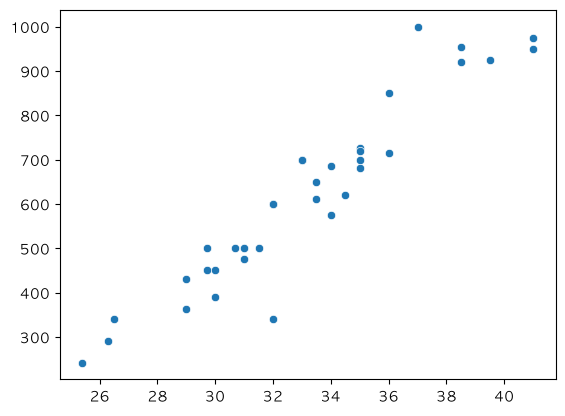

In [88]:
# bream: 도미(총 35개 데이터)
# ['Bream', 'Roach', 'Whitefish', 'Parkki', 'Perch', 'Pike', 'Smelt']
bream_length = list(df[df["Species"] == "Bream"]["Length"])
bream_weight = list(df[df["Species"] == "Bream"]["Weight"])

# 선형 데이터 
sns.scatterplot(x= bream_length, y=bream_weight)
plt.show()

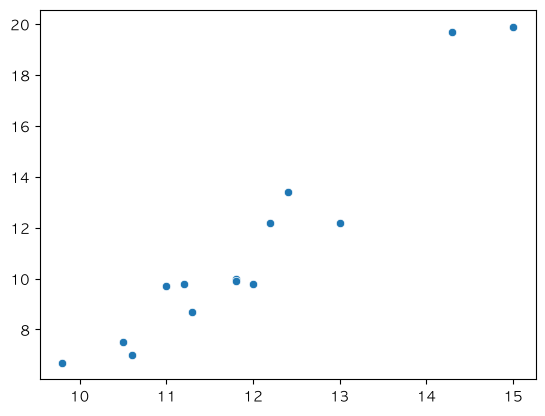

In [89]:
# Smelt: 빙어(총 14개)
# ['Bream', 'Roach', 'Whitefish', 'Parkki', 'Perch', 'Pike', 'Smelt']
smelt_length = list(df[df["Species"] == "Smelt"]["Length"])
smelt_weight = list(df[df["Species"] == "Smelt"]["Weight"])

# 선형데이터
sns.scatterplot(x=smelt_length, y=smelt_weight)
plt.show()

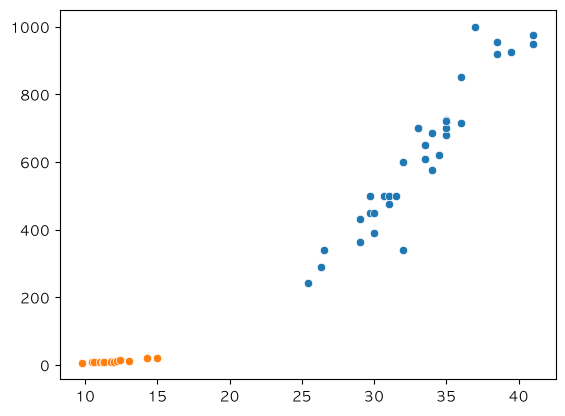

In [90]:
sns.scatterplot(x=bream_length, y=bream_weight)
sns.scatterplot(x=smelt_length, y=smelt_weight)

plt.show()

In [91]:
# .isin: 리스트 안에 ""이 값이 들어있는지 확인 
fish_df = df[df["Species"].isin(["Bream", "Smelt"])]
fish_df.head()

,Species,Weight,Length,Diagonal,Height,Width
0,Bream,242.0,25.4,30.0,11.5200,4.0200
1,Bream,290.0,26.3,31.2,12.4800,4.3056
2,Bream,340.0,26.5,31.1,12.3778,4.6961
3,Bream,363.0,29.0,33.5,12.7300,4.4555
4,Bream,430.0,29.0,34.0,12.4440,5.1340


In [92]:
# 인코딩 : 분류형, 수치형바꾸는 것 

## 분류형 인코딩 

In [93]:
# "Bream"은 0으로, "Smelt"은 1로 바꿔서 -> specie에 넣기 

# fish_df["Species"].map(lambda specie: {"Bream": 0, "Smelt": 1}[specie])

# 참조형
fish_df["Species"] = fish_df["Species"].map({"Bream":0, "Smelt": 1})
fish_df

,Species,Weight,Length,Diagonal,Height,Width
0,0,242.0,25.4,30.0,11.5200,4.0200
1,0,290.0,26.3,31.2,12.4800,4.3056
2,0,340.0,26.5,31.1,12.3778,4.6961
3,0,363.0,29.0,33.5,12.7300,4.4555
4,0,430.0,29.0,34.0,12.4440,5.1340
5,0,450.0,29.7,34.7,13.6024,4.9274
6,0,500.0,29.7,34.5,14.1795,5.2785
7,0,390.0,30.0,35.0,12.6700,4.6900
8,0,450.0,30.0,35.1,14.0049,4.8438
9,0,500.0,30.7,36.2,14.2266,4.9594


## 1단계, 데이터 준비 (탐색) 

In [94]:
fish_df.info()

<class 'pandas.DataFrame'>
Index: 49 entries, 0 to 158
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Species   49 non-null     int64  
 1   Weight    49 non-null     float64
 2   Length    49 non-null     float64
 3   Diagonal  49 non-null     float64
 4   Height    49 non-null     float64
 5   Width     49 non-null     float64
dtypes: float64(5), int64(1)
memory usage: 2.7 KB


In [95]:
fish_df.describe()

,Species,Weight,Length,Diagonal,Height,Width
count,49.000000,49.000000,49.000000,49.000000,49.000000,49.000000
mean,0.285714,444.500000,27.055102,31.120408,11.476400,4.259751
std,0.456435,328.143233,10.242804,12.097296,6.150976,1.967686
min,0.000000,6.700000,9.800000,10.800000,1.728400,1.047600
25%,0.000000,19.700000,14.300000,15.200000,2.872800,1.879200
50%,0.000000,500.000000,31.000000,36.200000,14.179500,5.072800
75%,1.000000,700.000000,34.500000,39.700000,15.633000,5.589000
max,1.000000,1000.000000,41.000000,46.500000,18.957000,6.749700


In [96]:
# [없앤 파일 복구]
# 1. 원본 df에서 사라진 컬럼들("Diagonal", "Height", "Width")만 인덱스 기준으로 다시 가져와 합칩니다.
missing_columns = ["Diagonal", "Height", "Width"]
fish_df[missing_columns] = df.loc[fish_df.index, missing_columns]

# 2. 복구가 완벽하게 되었는지 상위 5개 행을 확인합니다.
fish_df.head()



,Species,Weight,Length,Diagonal,Height,Width
0,0,242.0,25.4,30.0,11.5200,4.0200
1,0,290.0,26.3,31.2,12.4800,4.3056
2,0,340.0,26.5,31.1,12.3778,4.6961
3,0,363.0,29.0,33.5,12.7300,4.4555
4,0,430.0,29.0,34.0,12.4440,5.1340


In [97]:
fish_df= fish_df.drop(["Diagonal", "Height", "Width"], axis=1)
fish_df.head()

,Species,Weight,Length
0,0,242.0,25.4
1,0,290.0,26.3
2,0,340.0,26.5
3,0,363.0,29.0
4,0,430.0,29.0


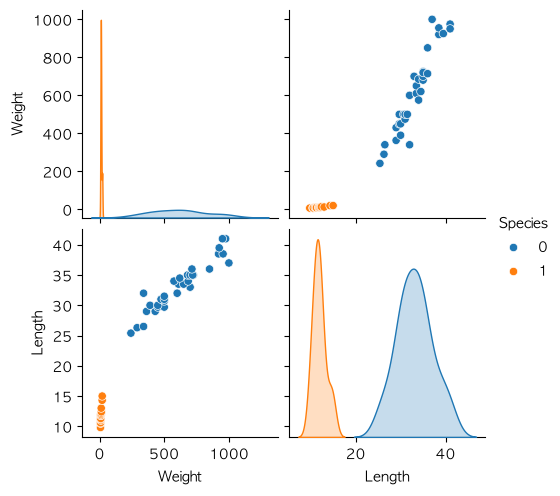

In [98]:
sns.pairplot(fish_df, hue="Species")
plt.show()

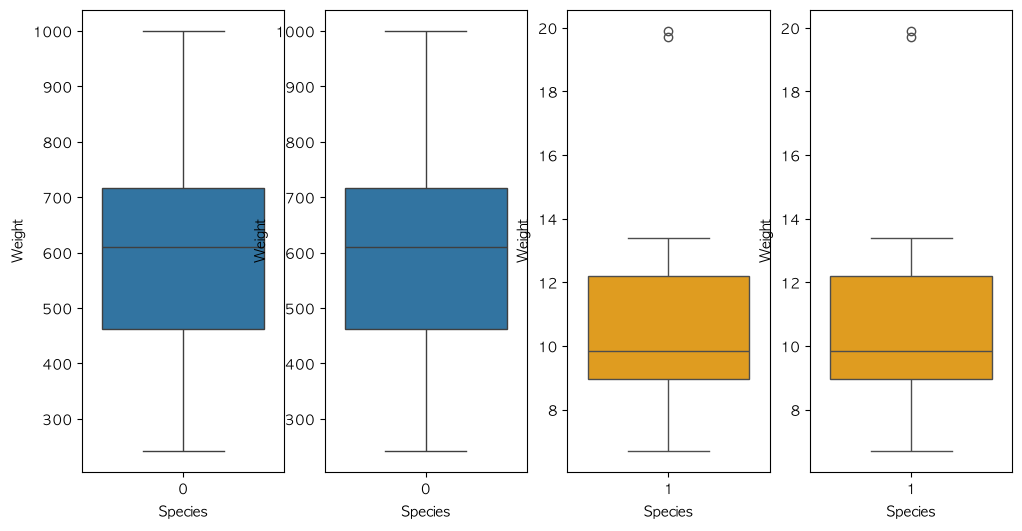

In [99]:
pig, axes = plt.subplots(1, 4, figsize=(12, 6))
sns.boxplot(fish_df[fish_df["Species"] == 0], x="Species", y="Weight", ax=axes[0])
sns.boxplot(fish_df[fish_df["Species"] == 0], x="Species", y="Weight", ax=axes[1])
sns.boxplot(fish_df[fish_df["Species"] == 1], x="Species", y="Weight", ax=axes[2],color="orange")
sns.boxplot(fish_df[fish_df["Species"] == 1], x="Species", y="Weight", ax=axes[3], color="orange")
plt.show()

## 2단계 , 데이터 분할 

In [100]:
# 독립 변수 , 종속 변수 
X= fish_df.drop("Species", axis=1)
X.head()

,Weight,Length
0,242.0,25.4
1,290.0,26.3
2,340.0,26.5
3,363.0,29.0
4,430.0,29.0


In [101]:
y = fish_df["Species"]
y.head()

0    0
1    0
2    0
3    0
4    0
Name: Species, dtype: int64

In [102]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=2026)
print(X_train.shape, X_test.shape, y_test.shape, y_train.shape)

(39, 2) (10, 2) (10,) (39,)


## 3단계 모델 준비

# KNN(ㅏ - 최근접 이웃, )알고리즘 
- 어떤 데이터에 대한 답을 구할 떄 주변의 다른 데이터를 보고 다수를 처자허는 데이터를 정답으로 정답하는 방식의 알고림즘

#  장점 
- 데이터만 있으면 알고리즘을 사용할 수 있다 

In [103]:
from sklearn.neighbors import KNeighborsClassifier

kn = KNeighborsClassifier()

## 4던계 모델 학습

In [104]:
# 표준화가 안된 쓰레기 데이터 
kn.fit(X_train, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"classes_ classes_: array of shape (n_classes,)Class labels known to the classifier","ndarray[int64](2,)","[0,1]"
"effective_metric_ effective_metric_: str or callbleThe distance metric used. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'


## 5던계, 모델 예측 

In [105]:
y_pred = kn.predict(X_test)
print(y_pred)
print(list(y_pred))

[0 1 0 0 0 0 0 1 1 0]
[np.int64(0), np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(1), np.int64(1), np.int64(0)]


## 6단계 모델 평가 

In [106]:
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

In [108]:
# print(f"accuracy_score: {kn.score(X_train, y_train)} ")
print(f"accuracy_score: {accuracy_score(y_test, y_pred)} ")

accuracy_score: 1.0 


In [ ]:
sns.scatterplot(fish_df, x="Length", y="W")

In [ ]:
columns = X_train.columnd

In [ ]:
# 거리  ,
distance, indexes = kn.kneighbor(new_data)
print(distance, indexes)

In [ ]:
sns.scatterplot(fish_df, x="")

In [ ]:
# StandardScaler: 표준화 
from sklearn.preprocessing import StandardScaler

# (데이터 값 - 평균) / 표준 편차
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
mean = np.mean(X_train, axis=0)
std = np.std(X_train, axis=0)
print(mean)
print(std)

In [ ]:
X_train_scaled_df = (X_train - mean) / std
X_train_scaled_df["Species"] = y_train
X_train_scaled_df.heaad()


In [ ]:
new_data_scaled = (new_data - mean) / std
new_data_scaled



In [ ]:
plt.scatterplot(X_train_scaled, x="Length", y="Weight", hue="Species")
plt.scatterplot(X_train_scaled, x="Length", y="Weight", hue="Species")
plt.show()

In [ ]:
plt.scatterplot(X_train_scaled, x="Length", y="Weight", hue="Species")
plt.scatterplot(X_train_scaled, x="Length", y="Weight", hue="Species")
plt.show()

## 사이킥런 모델학습 사이클 

In [ ]:
kn = KN

In [ ]:
kn.fit(X_train,_scaled, y_train) 

In [ ]:
y_pred= kn.predict(X_test_scaled)
y_pred

In [ ]:
acc

In [ ]:
# 혼돈 행렬 
cm comfusion_matrix(y_test, y_pred)
cm

In [ ]:
display = ConnectionMatrixDisply(confusion_matrix=cm, display_label=["도미 (0)", "빙어"])